In [2]:
# ============================================
# LOAN APPROVAL PREDICTION PROJECT
# ============================================

# Import Required Libraries

import pandas as pd
import numpy as np
import random

In [3]:
# Set Random Seed
np.random.seed(42)

# Number of Records
num_records = 2000

In [4]:
# Categories

genders = ["Male", "Female"]

employment_status = [
    "Employed",
    "Self-Employed",
    "Unemployed"
]

property_area = [
    "Urban",
    "Semi-Urban",
    "Rural"
]

In [5]:
# Generate Applicant Data

applicant_ids = np.arange(
    1001,
    1001 + num_records
)

gender_data = np.random.choice(
    genders,
    num_records
)

age_data = np.random.randint(
    21,
    60,
    num_records
)

income_data = np.random.randint(
    20000,
    150000,
    num_records
)

loan_amount_data = np.random.randint(
    50000,
    500000,
    num_records
)

credit_score_data = np.random.randint(
    300,
    900,
    num_records
)

employment_data = np.random.choice(
    employment_status,
    num_records
)

existing_loans_data = np.random.randint(
    0,
    5,
    num_records
)

loan_term_data = np.random.choice(
    [12, 24, 36, 60, 120, 180, 240, 360],
    num_records
)

property_area_data = np.random.choice(
    property_area,
    num_records
)

In [6]:
# Loan Approval Logic

loan_approval = []

for i in range(num_records):

    score = 0

    # High income increases approval chance
    if income_data[i] > 60000:
        score += 1

    # Good credit score increases approval
    if credit_score_data[i] > 650:
        score += 1

    # Employed applicants get advantage
    if employment_data[i] != "Unemployed":
        score += 1

    # Fewer existing loans preferred
    if existing_loans_data[i] < 2:
        score += 1

    # Final Decision
    if score >= 3:
        loan_approval.append(1)
    else:
        loan_approval.append(0)

In [7]:
# Create DataFrame

loan_df = pd.DataFrame({

    "ApplicantID": applicant_ids,

    "Gender": gender_data,

    "Age": age_data,

    "MonthlyIncome": income_data,

    "LoanAmount": loan_amount_data,

    "CreditScore": credit_score_data,

    "EmploymentStatus": employment_data,

    "ExistingLoans": existing_loans_data,

    "LoanTerm": loan_term_data,

    "PropertyArea": property_area_data,

    "LoanApproved": loan_approval
})

In [8]:
loan_df.head()

,ApplicantID,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
0,1001,Male,32,52441,389629,620,Self-Employed,2,60,Urban,0
1,1002,Female,36,126966,386199,478,Employed,2,24,Rural,0
2,1003,Male,44,59129,141911,518,Unemployed,1,120,Urban,0
3,1004,Male,39,120252,410762,827,Employed,0,24,Urban,1
4,1005,Male,28,82368,247742,791,Self-Employed,1,60,Semi-Urban,1


In [9]:
# Add Missing Values

loan_df.loc[
    loan_df.sample(frac=0.02).index,
    "CreditScore"
] = np.nan

loan_df.loc[
    loan_df.sample(frac=0.02).index,
    "EmploymentStatus"
] = np.nan

In [10]:
# Add Duplicate Records

duplicates = loan_df.sample(20)

loan_df = pd.concat([
    loan_df,
    duplicates
])

In [11]:
# Check Missing Values

loan_df.isnull().sum()

ApplicantID          0
Gender               0
Age                  0
MonthlyIncome        0
LoanAmount           0
CreditScore         40
EmploymentStatus    40
ExistingLoans        0
LoanTerm             0
PropertyArea         0
LoanApproved         0
dtype: int64

In [12]:
# Dataset Shape

loan_df.shape

(2020, 11)

In [13]:
# Save Dataset as CSV

loan_df.to_csv(
    "loan_dataset.csv",
    index=False
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [14]:
# Final Dataset Preview

print(loan_df.head())

print("\nDataset Shape:")
print(loan_df.shape)

print("\nMissing Values:")
print(loan_df.isnull().sum())

   ApplicantID  Gender  Age  MonthlyIncome  LoanAmount  CreditScore  \
0         1001    Male   32          52441      389629        620.0   
1         1002  Female   36         126966      386199        478.0   
2         1003    Male   44          59129      141911        518.0   
3         1004    Male   39         120252      410762        827.0   
4         1005    Male   28          82368      247742        791.0   

  EmploymentStatus  ExistingLoans  LoanTerm PropertyArea  LoanApproved  
0    Self-Employed              2        60        Urban             0  
1         Employed              2        24        Rural             0  
2       Unemployed              1       120        Urban             0  
3         Employed              0        24        Urban             1  
4    Self-Employed              1        60   Semi-Urban             1  

Dataset Shape:
(2020, 11)

Missing Values:
ApplicantID          0
Gender               0
Age                  0
MonthlyIncome        0

In [15]:
# Import Preprocessing Libraries

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

In [16]:
# Dataset Information

loan_df.info()

<class 'pandas.DataFrame'>
Index: 2020 entries, 0 to 81
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ApplicantID       2020 non-null   int64  
 1   Gender            2020 non-null   str    
 2   Age               2020 non-null   int32  
 3   MonthlyIncome     2020 non-null   int32  
 4   LoanAmount        2020 non-null   int32  
 5   CreditScore       1980 non-null   float64
 6   EmploymentStatus  1980 non-null   str    
 7   ExistingLoans     2020 non-null   int32  
 8   LoanTerm          2020 non-null   int64  
 9   PropertyArea      2020 non-null   str    
 10  LoanApproved      2020 non-null   int64  
dtypes: float64(1), int32(4), int64(3), str(3)
memory usage: 157.8 KB


In [17]:
# Missing Values Count

loan_df.isnull().sum()

ApplicantID          0
Gender               0
Age                  0
MonthlyIncome        0
LoanAmount           0
CreditScore         40
EmploymentStatus    40
ExistingLoans        0
LoanTerm             0
PropertyArea         0
LoanApproved         0
dtype: int64

In [18]:
# Fill Missing Credit Scores with Mean

loan_df["CreditScore"] = loan_df[
    "CreditScore"
].fillna(
    loan_df["CreditScore"].mean()
)

# Fill Missing Employment Status with Mode

loan_df["EmploymentStatus"] = loan_df[
    "EmploymentStatus"
].fillna(
    loan_df["EmploymentStatus"].mode()[0]
)

In [19]:
# Check Missing Values Again

loan_df.isnull().sum()

ApplicantID         0
Gender              0
Age                 0
MonthlyIncome       0
LoanAmount          0
CreditScore         0
EmploymentStatus    0
ExistingLoans       0
LoanTerm            0
PropertyArea        0
LoanApproved        0
dtype: int64

In [20]:
# Check Duplicate Rows

loan_df.duplicated().sum()

np.int64(20)

In [21]:
# Remove Duplicate Rows

loan_df.drop_duplicates(
    inplace=True
)

In [22]:
# Check Duplicates Again

loan_df.duplicated().sum()

np.int64(0)

In [23]:
# Create Label Encoder

label_encoder = LabelEncoder()

# Encode Gender

loan_df["Gender"] = label_encoder.fit_transform(
    loan_df["Gender"]
)

# Encode Employment Status

loan_df["EmploymentStatus"] = label_encoder.fit_transform(
    loan_df["EmploymentStatus"]
)

# Encode Property Area

loan_df["PropertyArea"] = label_encoder.fit_transform(
    loan_df["PropertyArea"]
)

In [24]:
loan_df.head()

,ApplicantID,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
0,1001,1,32,52441,389629,620.0,1,2,60,2,0
1,1002,0,36,126966,386199,478.0,0,2,24,0,0
2,1003,1,44,59129,141911,518.0,2,1,120,2,0
3,1004,1,39,120252,410762,827.0,0,0,24,2,1
4,1005,1,28,82368,247742,791.0,1,1,60,1,1


In [25]:
# Create Scaler

scaler = StandardScaler()

# Numerical Columns

numerical_columns = [
    "Age",
    "MonthlyIncome",
    "LoanAmount",
    "CreditScore",
    "ExistingLoans",
    "LoanTerm"
]

# Apply Scaling

loan_df[numerical_columns] = scaler.fit_transform(
    loan_df[numerical_columns]
)

In [26]:
loan_df.head()

,ApplicantID,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
0,1001,1,-0.728910,-0.851944,0.859915,0.148842,1,-0.050167,-0.607871,2,0
1,1002,0,-0.371294,1.136160,0.833292,-0.681463,0,-0.050167,-0.919094,0,0
2,1003,1,0.343937,-0.673528,-1.062772,-0.447574,2,-0.756752,-0.089165,2,0
3,1004,1,-0.103083,0.957051,1.023940,1.359216,0,-1.463336,-0.919094,2,1
4,1005,1,-1.086526,-0.053581,-0.241355,1.148716,1,-0.756752,-0.607871,1,1


In [27]:
# Save Processed Dataset

loan_df.to_csv(
    "processed_loan_dataset.csv",
    index=False
)

print("Processed Dataset Saved Successfully!")

Processed Dataset Saved Successfully!


In [28]:
# Import Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# First 5 Rows

loan_df.head()

,ApplicantID,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
0,1001,1,-0.728910,-0.851944,0.859915,0.148842,1,-0.050167,-0.607871,2,0
1,1002,0,-0.371294,1.136160,0.833292,-0.681463,0,-0.050167,-0.919094,0,0
2,1003,1,0.343937,-0.673528,-1.062772,-0.447574,2,-0.756752,-0.089165,2,0
3,1004,1,-0.103083,0.957051,1.023940,1.359216,0,-1.463336,-0.919094,2,1
4,1005,1,-1.086526,-0.053581,-0.241355,1.148716,1,-0.756752,-0.607871,1,1


In [30]:
# Dataset Information

loan_df.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ApplicantID       2000 non-null   int64  
 1   Gender            2000 non-null   int64  
 2   Age               2000 non-null   float64
 3   MonthlyIncome     2000 non-null   float64
 4   LoanAmount        2000 non-null   float64
 5   CreditScore       2000 non-null   float64
 6   EmploymentStatus  2000 non-null   int64  
 7   ExistingLoans     2000 non-null   float64
 8   LoanTerm          2000 non-null   float64
 9   PropertyArea      2000 non-null   int64  
 10  LoanApproved      2000 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 187.5 KB


In [31]:
# Statistical Summary

loan_df.describe()

,ApplicantID,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
count,2000.000000,2000.000000,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2000.000000,2.000000e+03,2.000000e+03,2000.000000,2000.00000
mean,2000.500000,0.508000,1.056932e-16,-1.678657e-16,-9.237056e-17,-5.009326e-16,0.928000,-1.301181e-16,2.486900e-17,0.986500,0.36000
std,577.494589,0.500061,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,0.825322,1.000250e+00,1.000250e+00,0.812187,0.48012
min,1001.000000,0.000000,-1.712353e+00,-1.714385e+00,-1.774480e+00,-1.722268e+00,0.000000,-1.463336e+00,-1.022835e+00,0.000000,0.00000
25%,1500.750000,0.000000,-8.183138e-01,-8.791946e-01,-8.566438e-01,-8.568794e-01,0.000000,-7.567518e-01,-9.190938e-01,0.000000,0.00000
50%,2000.500000,1.000000,-1.367880e-02,1.200119e-03,2.919485e-02,-9.032800e-03,1.000000,-5.016748e-02,-8.916543e-02,1.000000,0.00000
75%,2500.250000,1.000000,8.803601e-01,8.439936e-01,8.564257e-01,8.563555e-01,2.000000,6.564168e-01,9.482451e-01,2.000000,1.00000
max,3000.000000,1.000000,1.684995e+00,1.749945e+00,1.715118e+00,1.780216e+00,2.000000,1.363001e+00,1.985656e+00,2.000000,1.00000


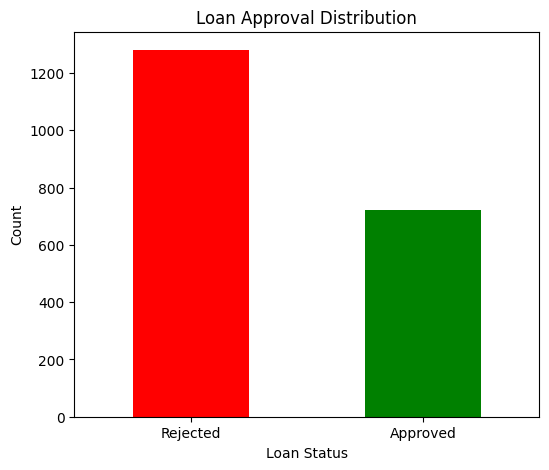

In [32]:
# Loan Approval Distribution

plt.figure(figsize=(6,5))

loan_df["LoanApproved"].value_counts().plot(
    kind="bar",
    color=["red", "green"]
)

plt.title("Loan Approval Distribution")

plt.xlabel("Loan Status")

plt.ylabel("Count")

plt.xticks(
    ticks=[0,1],
    labels=["Rejected", "Approved"],
    rotation=0
)

plt.show()

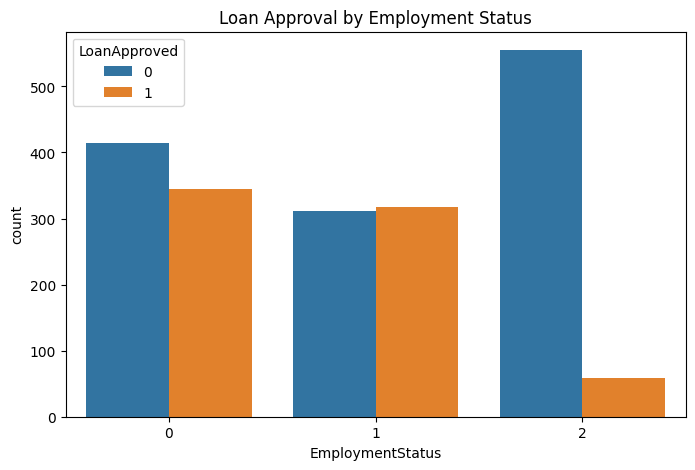

In [33]:
# Loan Approval by Employment Status

plt.figure(figsize=(8,5))

sns.countplot(
    x="EmploymentStatus",
    hue="LoanApproved",
    data=loan_df
)

plt.title(
    "Loan Approval by Employment Status"
)

plt.show()

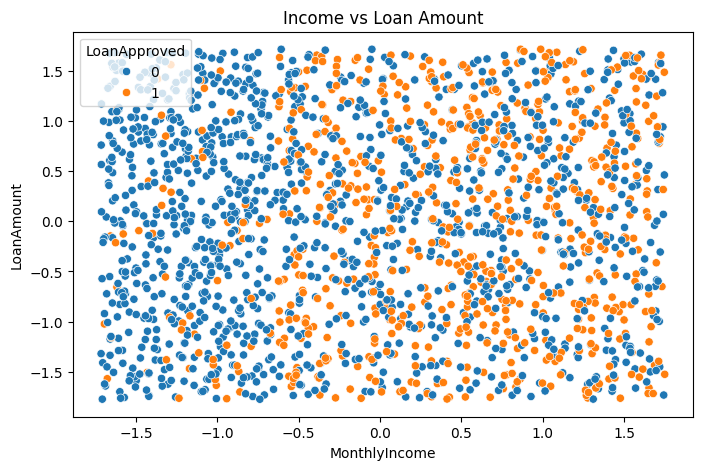

In [34]:
# Income vs Loan Amount

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="MonthlyIncome",
    y="LoanAmount",
    hue="LoanApproved",
    data=loan_df
)

plt.title(
    "Income vs Loan Amount"
)

plt.show()

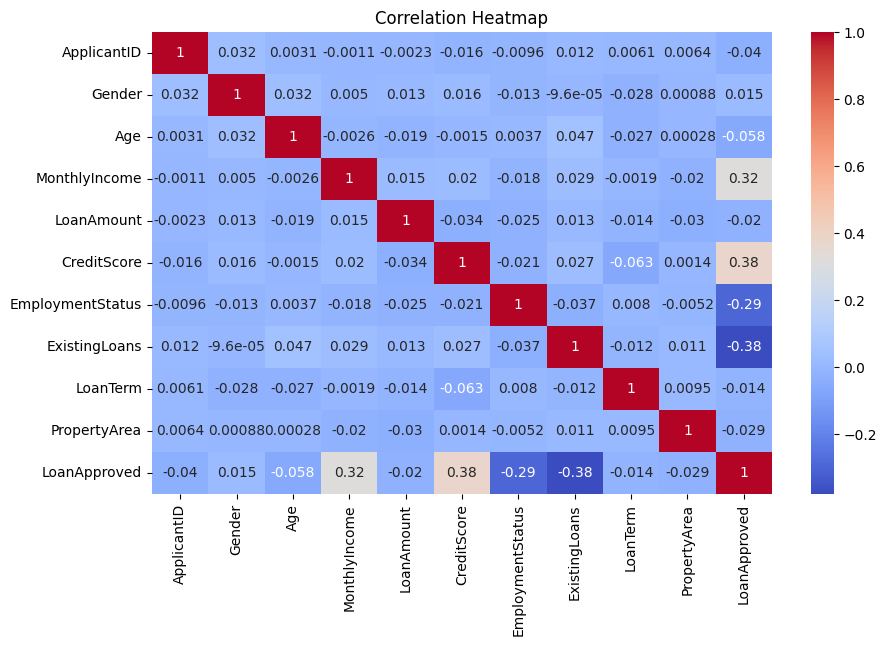

In [35]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

correlation_matrix = loan_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

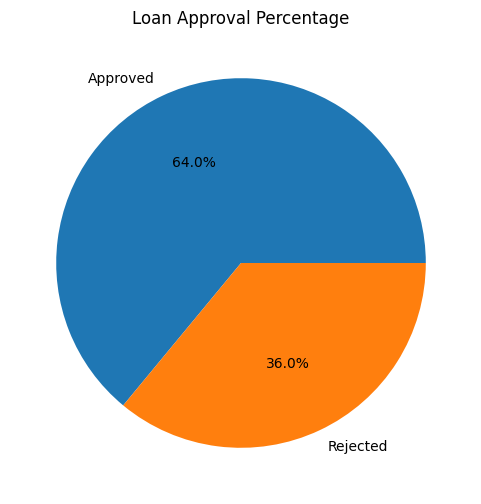

In [36]:
# Pie Chart of Loan Approval

loan_counts = loan_df[
    "LoanApproved"
].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    loan_counts,
    labels=["Approved", "Rejected"],
    autopct="%1.1f%%"
)

plt.title("Loan Approval Percentage")

plt.show()

In [37]:
# Key Insights

print("Key Insights:")

print(
    "- Higher credit scores improve approval chances."
)

print(
    "- Applicants with high income are approved more often."
)

print(
    "- Unemployed applicants face more rejections."
)

print(
    "- Existing loans negatively affect approvals."
)

Key Insights:
- Higher credit scores improve approval chances.
- Applicants with high income are approved more often.
- Unemployed applicants face more rejections.
- Existing loans negatively affect approvals.


In [38]:
# Import ML Libraries

from sklearn.model_selection import (
    train_test_split
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [39]:
# Features

X = loan_df.drop(
    "LoanApproved",
    axis=1
)

# Target Variable

y = loan_df["LoanApproved"]

In [40]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

In [41]:
# Dataset Shapes

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 10)
Testing Data Shape: (400, 10)


In [42]:
# Create Random Forest Model

model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

In [43]:
# Train Model

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:
# Predictions

y_pred = model.predict(X_test)

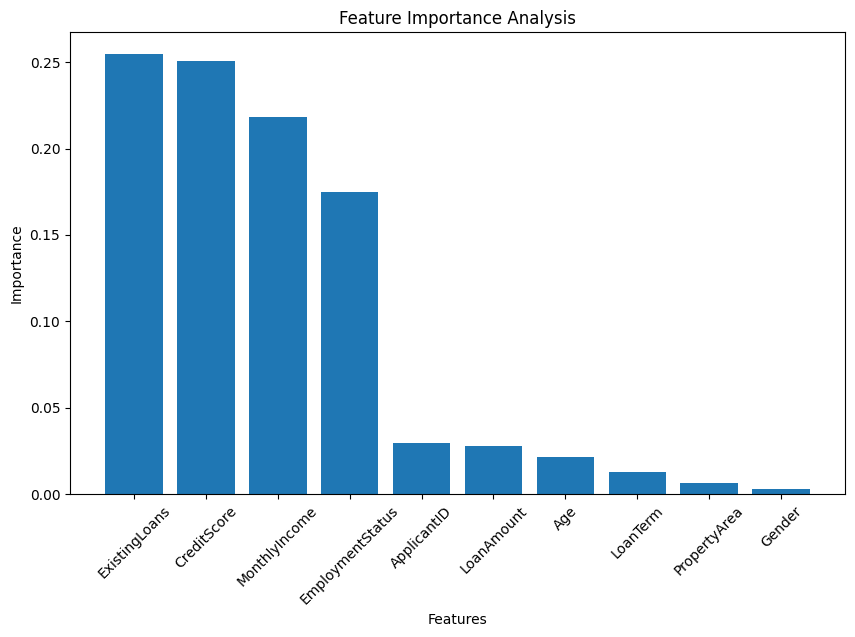

In [53]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    feature_importance_df['Feature'],
    feature_importance_df['Importance']
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance Analysis")

plt.show()

In [54]:
# ============================================
# MODEL COMPARISON
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

# Results
print("Logistic Regression Accuracy:", lr_accuracy)

print("Decision Tree Accuracy:", dt_accuracy)

print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.8675
Decision Tree Accuracy: 0.99
Random Forest Accuracy: 0.9925


In [45]:
# Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.9925


In [46]:
# Precision

precision = precision_score(
    y_test,
    y_pred
)

print("Precision Score:", precision)

Precision Score: 0.9871794871794872


In [47]:
# Recall

recall = recall_score(
    y_test,
    y_pred
)

print("Recall Score:", recall)

Recall Score: 0.9935483870967742


In [48]:
# F1 Score

f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)

F1 Score: 0.9903536977491961


In [49]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[243   2]
 [  1 154]]


In [50]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       245
           1       0.99      0.99      0.99       155

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



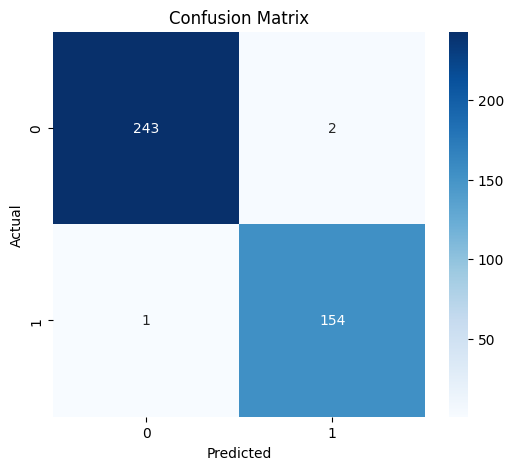

In [51]:
# Confusion Matrix Heatmap

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()